<a href="https://colab.research.google.com/github/Arnold-XV/cvl_assignment1/blob/main/CVL_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Image Enhancement by Histogram Equalization

In [28]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [33]:
#change the name according to the image that you want to enhance
filename = "lowlight3.jpg"

In [34]:
# load image
gray = np.array(Image.open(filename).convert("L"))

print(f"Image size: {gray.shape[1]} x {gray.shape[0]} pixels")
print(f"Pixel range: [{gray.min()}, {gray.max()}]")

Image size: 1120 x 640 pixels
Pixel range: [0, 254]


In [35]:
def histogram_equalization(image):
    rows, cols = image.shape
    total_pixels = rows * cols

    # manual histogram mapping
    histogram = [0] * 256
    for i in range(rows):
        for j in range(cols):
            histogram[image[i, j]] += 1

    # cdf
    cdf = [0] * 256
    cdf[0] = histogram[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + histogram[i]

    # find minimum non-zero cdf value
    cdf_min = 0
    for i in range(256):
        if cdf[i] != 0:
            cdf_min = cdf[i]
            break

    # normalize CDF
    lookup = [0] * 256
    for i in range(256):
        lookup[i] = round((cdf[i] - cdf_min) / (total_pixels - cdf_min) * 255)

    # pixel mapping
    result = np.zeros_like(image)
    for i in range(rows):
        for j in range(cols):
            result[i, j] = lookup[image[i, j]]
    return result

equalized = histogram_equalization(gray)
print(f"Histogram range before: [{gray.min()}, {gray.max()}]")
print(f"Histogram range after: [{equalized.min()}, {equalized.max()}]")

Histogram range before: [0, 254]
Histogram range after: [0, 255]


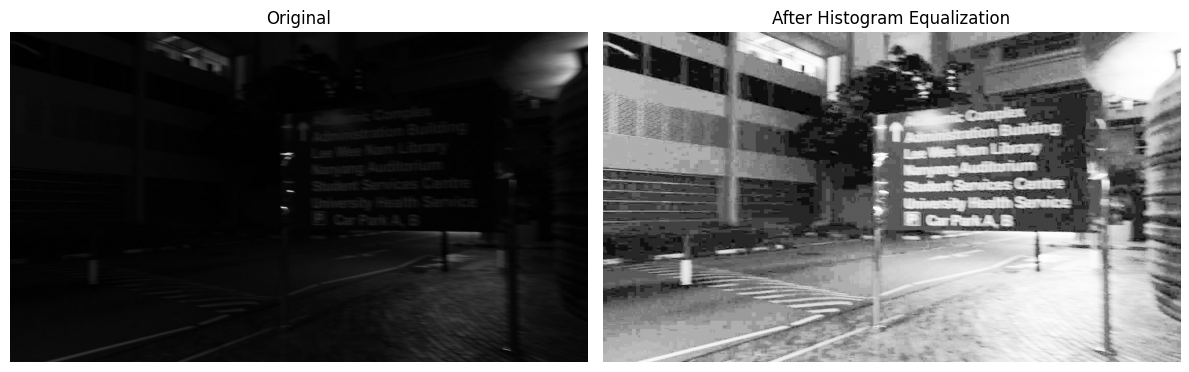

In [36]:
#display the image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(gray, cmap='gray', vmin=0, vmax=255)
ax1.set_title('Original')
ax1.axis('off')

ax2.imshow(equalized, cmap='gray', vmin=0, vmax=255)
ax2.set_title('After Histogram Equalization')
ax2.axis('off')

plt.tight_layout()
plt.show()